In [12]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results folder: {OUT_DIR}")

Project root: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking
Results folder: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results


# Cost function experiment

This notebook searches for robust cost-function settings specifically for the **trajectory-to-trajectory assignment task**, which aims at assigning reconstructed trajectories to their corresponding identified Ground Truth (GT) trajectories. This task is only relevant in the context of simulated data for evaluation purposes, in contrast to the peak-to-peak assignment task which plays a central role in any tracking pipeline.

To label reconstructed trajectories to their best corresponding GT trajectories, the parameters studied in the cost function for the assignment are the trajectory position (computed as its center of gravity), length, and start and end frames. After the costs are set, we choose the Hungarian algorithm for the assignemnt task itself. 

We evaluate the quality of this trajectory-to-trajectory assignment is evaluated according to the following metrics:  

- IDF1: best single metric for identity relabelling.
- GT coverage: how much of the GT trajectory is recovered.
- Median assigned-position error: spatial correctness of assigned tracks.

In [13]:
import copy
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from IPython.display import display

from helpers.helpersSimulation import Simulator
from helpers.helpersTracking import (
    extract_peaks,
    track_from_peaks,
    track_peaks_to_trajectories,
    PeakToPeak,
    DistanceTerm,
    IntensityTerm,
    SigmaTerm,
)
from helpers.helpersAssignment import (
    TrajToTraj,
    MeanPositionDistanceTerm,
    LengthDifferenceTerm,
    StartFrameDifferenceTerm,
    assign_trajectories,
)
from helpers.helpersPlotting import linear_trajectories_visualizer

# British-spelling alias for report/notebook text.
linear_trajectories_visualiser = linear_trajectories_visualizer

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
})

## Experiment design

In [14]:
N_SEEDS = 1
SEEDS = list(range(N_SEEDS))

NFRAMES = 50
NPOSFRAME = 10

DIFFICULTY_SETUPS = [
    {"setup": "S1", "nparticles": 5, "intensity_mean": 800, "intensity_std": 50},
    {"setup": "S2", "nparticles": 10, "intensity_mean": 700, "intensity_std": 100},
    {"setup": "S3", "nparticles": 15, "intensity_mean": 600, "intensity_std": 150},
    {"setup": "S4", "nparticles": 20, "intensity_mean": 550, "intensity_std": 200},
    {"setup": "S5", "nparticles": 25, "intensity_mean": 500, "intensity_std": 300},
]

DIFFICULTY_LABELS = [
    f"{cfg['setup']} (N={cfg['nparticles']}, I={cfg['intensity_mean']}+/-{cfg['intensity_std']})"
    for cfg in DIFFICULTY_SETUPS
]

def difficulty_label(setup):
    return (
        f"{setup['setup']} "
        f"(N={setup['nparticles']}, "
        f"I={setup['intensity_mean']}+/-{setup['intensity_std']})"
    )

D_LIST = [
    (0.02, 0.16),
    (0.08, 0.14),
    (0.25, 0.14),
    (0.75, 0.14),
    (2.00, 0.14),
    (4.50, 0.14),
    (8.00, 0.14),
]

SIM_CONFIG_BASE = {
    "nparticles": None,
    "nframes": NFRAMES,
    "nposframe": NPOSFRAME,
    "D_list": D_LIST,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0), # isotropic diffusion
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": None,
    "intensity_std": None,
    "sigma_mean": 1.0,
    "sigma_std": 0.2,
}

IMAGE_CONFIG_BASE = {}

TRACKING_KWARGS = {
    "mode": "localization",
    "detection_threshold": 400,
    "r_squared_threshold": 0.45,
    "max_distance": 8.0,
    "min_length": 5,
    "max_gap": 1,
    "algo_peak2peak": "hungarian",
    "algo_traj2traj": "hungarian",
}

# Fixed peak-to-peak cost selected from previous HOTA optimization
BEST_PEAK_SPEC = {
    "name": "dist_int_60_40",
    "family": "distance_intensity",
    "distance": 0.60,
    "intensity": 0.40,
    "sigma": 0.00,
}

PEAK_NORMS = {
    "distance": TRACKING_KWARGS["max_distance"],
    "intensity": 700.0,
    "sigma": 0.75,
}

BEST_PEAK_COST = PeakToPeak(
    terms={
        "distance": DistanceTerm(
            weight=BEST_PEAK_SPEC["distance"],
            norm=PEAK_NORMS["distance"],
        ),
        "intensity": IntensityTerm(
            weight=BEST_PEAK_SPEC["intensity"],
            norm=PEAK_NORMS["intensity"],
        ),
    }
)

TRAJ_NORMS = {
    "position": TRACKING_KWARGS["max_distance"],
    "length": 10.0,
    "start_frame": 5.0,
}

TRUTH_MATCH_TOLERANCE_PX = 3.0
TRAJ_SELECTION_METRIC = "idf1"
CACHE_VERSION = "traj2traj_idf1_v1"
FORCE_RERUN = False

# keep unfragmented GTs but that may be shorter and start later than the first frame
GT_FRAGMENTATION = {
    "enabled": False,
    "min_fragment_length": 10,
    "max_fragments_per_gt": 1,
    "max_start_drop_frac": 0.25,
    "max_end_drop_frac": 0.20,
    "gap_range": (1, 5),
}

REQUIRED_RESULT_COLUMNS = {
    "idf1",
    "id_precision",
    "id_recall",
    "mean_coverage",
    "median_position_error_px",
    "link_f1",
    "link_recall",
    "hota",
    "deta",
    "assa",
    "mota",
    "motp_px",
    "id_switches",
    "fragmentations",
    "cache_version",
}


RESULT_STEM = "CostT2TExperiment_difficulty_intensity"
RESULT_PATHS = {
    "traj": OUT_DIR / f"{RESULT_STEM}_traj2traj_results.csv",
    "summary": OUT_DIR / f"{RESULT_STEM}_recommendations.csv",
    "traj_figure_png": OUT_DIR / f"{RESULT_STEM}_tracking_metrics_traj.png",
    "traj_figure_pdf": OUT_DIR / f"{RESULT_STEM}_tracking_metrics_traj.pdf",
    "gt_viz_png": OUT_DIR / f"{RESULT_STEM}_fragmented_gt.png",
    "gt_viz_pdf": OUT_DIR / f"{RESULT_STEM}_fragmented_gt.pdf",
    "best_viz_png": OUT_DIR / f"{RESULT_STEM}_best_trajectories_vs_gt.png",
    "best_viz_pdf": OUT_DIR / f"{RESULT_STEM}_best_trajectories_vs_gt.pdf",
}

print(f"Simulations: {len(SEEDS) * len(DIFFICULTY_SETUPS)}")
print(f"Frames per simulation: {NFRAMES}, positions per frame: {NPOSFRAME}")
print(f"Fixed peak-to-peak cost: {BEST_PEAK_SPEC['name']}")
print(f"Trajectory selection metric: {TRAJ_SELECTION_METRIC}")

Simulations: 5
Frames per simulation: 50, positions per frame: 10
Fixed peak-to-peak cost: dist_int_60_40
Trajectory selection metric: idf1


## Cost grids

In [15]:
TRAJ_COST_SPECS = [
    {"name": "position_only", "family": "ablation", "position": 1.00, "length": 0.00, "start_frame": 0.00},
    {"name": "length_only", "family": "ablation", "position": 0.00, "length": 1.00, "start_frame": 0.00},
    {"name": "start_only", "family": "ablation", "position": 0.00, "length": 0.00, "start_frame": 1.00},
    {"name": "pos_len_90_10", "family": "position_length", "position": 0.90, "length": 0.10, "start_frame": 0.00},
    {"name": "pos_len_75_25", "family": "position_length", "position": 0.75, "length": 0.25, "start_frame": 0.00},
    {"name": "pos_len_60_40", "family": "position_length", "position": 0.60, "length": 0.40, "start_frame": 0.00},
    {"name": "pos_start_90_10", "family": "position_start", "position": 0.90, "length": 0.00, "start_frame": 0.10},
    {"name": "pos_start_75_25", "family": "position_start", "position": 0.75, "length": 0.00, "start_frame": 0.25},
    {"name": "pos_start_60_40", "family": "position_start", "position": 0.60, "length": 0.00, "start_frame": 0.40},
    {"name": "pos_meta_80_10_10", "family": "all_terms", "position": 0.80, "length": 0.10, "start_frame": 0.10},
    {"name": "pos_meta_70_20_10", "family": "all_terms", "position": 0.70, "length": 0.20, "start_frame": 0.10},
    {"name": "pos_meta_60_20_20", "family": "all_terms", "position": 0.60, "length": 0.20, "start_frame": 0.20},
    {"name": "equal_all", "family": "all_terms", "position": 1/3, "length": 1/3, "start_frame": 1/3},
]

def build_peak_cost(spec):
    terms = {}
    if spec.get("distance", 0) > 0:
        terms["distance"] = DistanceTerm(weight=float(spec["distance"]), norm=PEAK_NORMS["distance"])
    if spec.get("intensity", 0) > 0:
        terms["intensity"] = IntensityTerm(weight=float(spec["intensity"]), norm=PEAK_NORMS["intensity"])
    if spec.get("sigma", 0) > 0:
        terms["sigma"] = SigmaTerm(weight=float(spec["sigma"]), norm=PEAK_NORMS["sigma"])
    return PeakToPeak(terms=terms)

def build_traj_cost(spec):
    terms = {}
    if spec.get("position", 0) > 0:
        terms["position"] = MeanPositionDistanceTerm(
            weight=float(spec["position"]),
            norm=TRAJ_NORMS["position"],
            invalid_cost=1e6,
        )
    if spec.get("length", 0) > 0:
        terms["length"] = LengthDifferenceTerm(weight=float(spec["length"]), norm=TRAJ_NORMS["length"])
    if spec.get("start_frame", 0) > 0:
        terms["start_frame"] = StartFrameDifferenceTerm(
            weight=float(spec["start_frame"]),
            norm=TRAJ_NORMS["start_frame"],
        )
    return TrajToTraj(terms=terms)

FIXED_TRAJ_EVALUATOR_SPEC = next(spec for spec in TRAJ_COST_SPECS if spec["name"] == "position_only")
FIXED_TRAJ_EVALUATOR = build_traj_cost(FIXED_TRAJ_EVALUATOR_SPEC)

display(pd.DataFrame(TRAJ_COST_SPECS))

,name,family,position,length,start_frame
0,position_only,ablation,1.000000,0.000000,0.000000
1,length_only,ablation,0.000000,1.000000,0.000000
2,start_only,ablation,0.000000,0.000000,1.000000
3,pos_len_90_10,position_length,0.900000,0.100000,0.000000
4,pos_len_75_25,position_length,0.750000,0.250000,0.000000
5,pos_len_60_40,position_length,0.600000,0.400000,0.000000
6,pos_start_90_10,position_start,0.900000,0.000000,0.100000
7,pos_start_75_25,position_start,0.750000,0.000000,0.250000
8,pos_start_60_40,position_start,0.600000,0.000000,0.400000
9,pos_meta_80_10_10,all_terms,0.800000,0.100000,0.100000


## Metrics

In [16]:
import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import linear_sum_assignment


def finite_mean(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.mean(values)) if len(values) else np.nan


def finite_median(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.median(values)) if len(values) else np.nan


def finite_sem(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) <= 1:
        return np.nan
    return float(np.std(values, ddof=1) / np.sqrt(len(values)))


def valid_gt_id(gid, gt_by_id):
    return gid is not None and gid != -1 and gid in gt_by_id


def edge_counter(trajectories, require_valid_gt=True, gt_by_id=None):
    edges = Counter()

    for traj in trajectories:
        gid = traj.id

        if require_valid_gt and not valid_gt_id(gid, gt_by_id):
            continue

        frames = sorted(traj.frames())
        for f0, f1 in zip(frames[:-1], frames[1:]):
            if f1 == f0 + 1:
                edges[(int(gid), int(f0), int(f1))] += 1

    return edges


def precision_recall_f1(pred_edges, gt_edges):
    tp = sum(min(count, gt_edges.get(edge, 0)) for edge, count in pred_edges.items())
    fp = sum(pred_edges.values()) - tp
    fn = sum(gt_edges.values()) - tp

    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan

    f1 = (
        2 * precision * recall / (precision + recall)
        if np.isfinite(precision)
        and np.isfinite(recall)
        and (precision + recall) > 0
        else np.nan
    )

    return precision, recall, f1, tp, fp, fn


def detections_by_frame(trajectories, identity="track"):
    by_frame = {}

    for track_idx, traj in enumerate(trajectories):
        if traj.length() == 0:
            continue

        det_id = track_idx if identity == "track" else traj.id

        if identity == "gt" and (det_id is None or det_id == -1):
            continue

        for frame in traj.frames():
            pos = traj.get_position_at_frame(frame)
            if pos is None:
                continue

            by_frame.setdefault(int(frame), []).append({
                "id": det_id,
                "pos": np.asarray(pos, dtype=float),
            })

    return by_frame


def match_detections_by_frame(
    trajectories,
    trajectories_gt,
    tolerance_px=TRUTH_MATCH_TOLERANCE_PX,
):
    pred_by_frame = detections_by_frame(trajectories, identity="track")
    gt_by_frame = detections_by_frame(trajectories_gt, identity="gt")

    total_pred = sum(len(v) for v in pred_by_frame.values())
    total_gt = sum(len(v) for v in gt_by_frame.values())

    match_rows = []

    for frame in sorted(set(pred_by_frame) | set(gt_by_frame)):
        preds = pred_by_frame.get(frame, [])
        gts = gt_by_frame.get(frame, [])

        if not preds or not gts:
            continue

        cost = np.empty((len(preds), len(gts)), dtype=float)

        for i, pred in enumerate(preds):
            for j, gt in enumerate(gts):
                cost[i, j] = float(np.linalg.norm(pred["pos"] - gt["pos"]))

        row_ind, col_ind = linear_sum_assignment(cost)

        for i, j in zip(row_ind, col_ind):
            error_px = float(cost[i, j])
            if error_px <= tolerance_px:
                match_rows.append({
                    "frame": int(frame),
                    "gt_id": gts[j]["id"],
                    "track_id": preds[i]["id"],
                    "error_px": error_px,
                })

    return pd.DataFrame(match_rows), total_pred, total_gt


def fragmentation_count(gt_frames, matched_frames):
    matched_frames = set(matched_frames)

    was_matched = False
    has_been_matched = False
    n_fragments = 0

    for frame in sorted(gt_frames):
        is_matched = frame in matched_frames

        if is_matched and has_been_matched and not was_matched:
            n_fragments += 1

        if is_matched:
            has_been_matched = True

        was_matched = is_matched

    return n_fragments


def tracking_event_metrics(
    trajectories,
    trajectories_gt,
    tolerance_px=TRUTH_MATCH_TOLERANCE_PX,
):
    matches, total_pred, total_gt = match_detections_by_frame(
        trajectories,
        trajectories_gt,
        tolerance_px=tolerance_px,
    )

    gt_by_id = {
        traj.id: traj
        for traj in trajectories_gt
        if traj.id is not None and traj.length() > 0
    }

    tp = int(len(matches))
    fp = int(total_pred - tp)
    fn = int(total_gt - tp)

    errors = matches["error_px"].to_numpy(dtype=float) if tp else np.asarray([], dtype=float)

    # Detection accuracy
    deta = tp / (tp + fp + fn) if (tp + fp + fn) else np.nan

    # Association accuracy / HOTA-like score
    if tp:
        pair_counts = Counter(zip(matches["gt_id"], matches["track_id"]))
        gt_counts = Counter(matches["gt_id"])
        track_counts = Counter(matches["track_id"])

        ass_scores = []
        for gt_id, track_id in zip(matches["gt_id"], matches["track_id"]):
            tpa = pair_counts[(gt_id, track_id)]
            fna = gt_counts[gt_id] - tpa
            fpa = track_counts[track_id] - tpa
            ass_scores.append(tpa / (tpa + fna + fpa))

        assa = finite_mean(ass_scores)
    else:
        assa = np.nan

    hota = (
        float(np.sqrt(deta * assa))
        if np.isfinite(deta) and np.isfinite(assa)
        else np.nan
    )

    # ID switches
    id_switches = 0
    if tp:
        for gid in gt_by_id:
            gt_matches = matches[matches["gt_id"] == gid].sort_values("frame")
            previous_track = None

            for track_id in gt_matches["track_id"].tolist():
                if previous_track is not None and track_id != previous_track:
                    id_switches += 1
                previous_track = track_id

    mota = 1.0 - (fn + fp + id_switches) / total_gt if total_gt else np.nan

    # Coverage and fragmentations
    matched_frames_by_gt = {gid: set() for gid in gt_by_id}

    if tp:
        for row in matches.itertuples(index=False):
            if row.gt_id in matched_frames_by_gt:
                matched_frames_by_gt[row.gt_id].add(int(row.frame))

    coverage = []
    fragmentations_per_gt = []

    for gid, gt_traj in gt_by_id.items():
        gt_frames = [
            int(frame)
            for frame in gt_traj.frames()
            if gt_traj.get_position_at_frame(frame) is not None
        ]

        matched_frames = matched_frames_by_gt[gid]

        coverage.append(
            len(matched_frames) / len(gt_frames)
            if gt_frames else np.nan
        )

        fragmentations_per_gt.append(
            fragmentation_count(gt_frames, matched_frames)
        )

    # ID metrics
    idtp = tp
    idfp = fp
    idfn = fn

    id_precision = idtp / (idtp + idfp) if (idtp + idfp) else np.nan
    id_recall = idtp / (idtp + idfn) if (idtp + idfn) else np.nan

    idf1 = (
        2 * id_precision * id_recall / (id_precision + id_recall)
        if np.isfinite(id_precision)
        and np.isfinite(id_recall)
        and (id_precision + id_recall) > 0
        else np.nan
    )

    return {
        "clear_tp": tp,
        "clear_fp": fp,
        "clear_fn": fn,

        "deta": deta,
        "assa": assa,
        "hota": hota,

        "mota": mota,
        "motp_px": finite_mean(errors),

        "idtp": idtp,
        "idfp": idfp,
        "idfn": idfn,
        "id_precision": id_precision,
        "id_recall": id_recall,
        "idf1": idf1,

        "id_switches": int(id_switches),
        "fragmentations": int(np.nansum(fragmentations_per_gt)) if len(fragmentations_per_gt) else 0,
        "mean_fragmentations_per_gt": finite_mean(fragmentations_per_gt),

        "matched_position_errors": errors,
        "coverage": np.asarray(coverage, dtype=float),
        "fragmentations_per_gt": np.asarray(fragmentations_per_gt, dtype=float),
    }


def assigned_position_errors(trajectories, gt_by_id):
    errors = []

    for traj in trajectories:
        if not valid_gt_id(traj.id, gt_by_id):
            continue

        gt_traj = gt_by_id[traj.id]

        for frame in traj.frames():
            pos = traj.get_position_at_frame(frame)
            gt_pos = gt_traj.get_position_at_frame(frame)

            if pos is None or gt_pos is None:
                continue

            errors.append(float(np.linalg.norm(np.asarray(pos) - np.asarray(gt_pos))))

    return np.asarray(errors, dtype=float)


def coverage_and_fragments(trajectories, trajectories_gt):
    gt_by_id = {
        traj.id: traj
        for traj in trajectories_gt
        if traj.id is not None and traj.length() > 0
    }

    recovered_frames = {gid: set() for gid in gt_by_id}
    fragment_counts = {gid: 0 for gid in gt_by_id}

    assigned_tracks = 0
    unassigned_tracks = 0

    for traj in trajectories:
        if traj.length() == 0:
            continue

        if not valid_gt_id(traj.id, gt_by_id):
            unassigned_tracks += 1
            continue

        assigned_tracks += 1
        fragment_counts[traj.id] += 1

        gt_traj = gt_by_id[traj.id]

        for frame in traj.frames():
            if gt_traj.get_position_at_frame(frame) is not None:
                recovered_frames[traj.id].add(frame)

    coverage = []
    fragments = []

    for gid, gt_traj in gt_by_id.items():
        coverage.append(len(recovered_frames[gid]) / gt_traj.length())
        fragments.append(fragment_counts[gid])

    return {
        "coverage": np.asarray(coverage, dtype=float),
        "fragments": np.asarray(fragments, dtype=float),
        "assigned_tracks": assigned_tracks,
        "unassigned_tracks": unassigned_tracks,
    }


def score_labeled_trajectories(
    trajectories,
    trajectories_gt,
    runtime_s,
    extra=None,
):
    gt_by_id = {
        traj.id: traj
        for traj in trajectories_gt
        if traj.id is not None and traj.length() > 0
    }

    gt_edges = edge_counter(trajectories_gt, require_valid_gt=False)
    pred_edges = edge_counter(
        trajectories,
        require_valid_gt=True,
        gt_by_id=gt_by_id,
    )

    precision, recall, f1, tp, fp, fn = precision_recall_f1(pred_edges, gt_edges)

    assigned_errors = assigned_position_errors(trajectories, gt_by_id)
    cov_frag = coverage_and_fragments(trajectories, trajectories_gt)
    event_metrics = tracking_event_metrics(trajectories, trajectories_gt)

    matched_errors = event_metrics["matched_position_errors"]

    row = {
        "runtime_s": runtime_s,
        "n_tracks": len([traj for traj in trajectories if traj.length() > 0]),

        "link_precision": precision,
        "link_recall": recall,
        "link_f1": f1,
        "link_tp": tp,
        "link_fp": fp,
        "link_fn": fn,

        "mean_coverage": finite_mean(event_metrics["coverage"]),
        "median_coverage": finite_median(event_metrics["coverage"]),

        "mean_assigned_coverage": finite_mean(cov_frag["coverage"]),
        "mean_fragments_per_gt": finite_mean(cov_frag["fragments"]),
        "max_fragments_per_gt": (
            float(np.nanmax(cov_frag["fragments"]))
            if len(cov_frag["fragments"]) else np.nan
        ),

        "assigned_tracks": cov_frag["assigned_tracks"],
        "unassigned_tracks": cov_frag["unassigned_tracks"],

        "median_position_error_px": finite_median(matched_errors),
        "mean_position_error_px": finite_mean(matched_errors),

        "assigned_median_position_error_px": finite_median(assigned_errors),
        "assigned_mean_position_error_px": finite_mean(assigned_errors),

        "clear_tp": event_metrics["clear_tp"],
        "clear_fp": event_metrics["clear_fp"],
        "clear_fn": event_metrics["clear_fn"],

        "deta": event_metrics["deta"],
        "assa": event_metrics["assa"],
        "hota": event_metrics["hota"],

        "mota": event_metrics["mota"],
        "motp_px": event_metrics["motp_px"],

        "idtp": event_metrics["idtp"],
        "idfp": event_metrics["idfp"],
        "idfn": event_metrics["idfn"],
        "id_precision": event_metrics["id_precision"],
        "id_recall": event_metrics["id_recall"],
        "idf1": event_metrics["idf1"],

        "id_switches": event_metrics["id_switches"],
        "fragmentations": event_metrics["fragmentations"],
        "mean_fragmentations_per_gt": event_metrics["mean_fragmentations_per_gt"],
    }

    if extra:
        row.update(extra)

    return row


def add_selection_scores(df):
    df = df.copy()

    missing = REQUIRED_RESULT_COLUMNS - set(df.columns)
    if missing:
        raise ValueError(
            "Results are missing columns: "
            + ", ".join(sorted(missing))
            + ". Rerun the sweep."
        )

    df["traj_objective"] = df[TRAJ_SELECTION_METRIC]

    return df


def summarize_by_config(df, config_col, objective_col):
    metric_cols = [
        objective_col,

        "idf1",
        "id_precision",
        "id_recall",

        "mean_coverage",
        "median_position_error_px",
        "mean_position_error_px",

        "link_precision",
        "link_recall",
        "link_f1",

        "hota",
        "deta",
        "assa",
        "mota",
        "motp_px",

        "id_switches",
        "fragmentations",
        "mean_fragmentations_per_gt",

        "n_tracks",
        "assigned_tracks",
        "unassigned_tracks",
        "runtime_s",
    ]

    rows = []

    for name, group in df.groupby(config_col):
        row = {config_col: name, "n": len(group)}

        for metric in metric_cols:
            if metric not in group.columns:
                continue

            values = group[metric].to_numpy(dtype=float)
            row[f"{metric}_mean"] = finite_mean(values)
            row[f"{metric}_ci95"] = 1.96 * finite_sem(values)

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values(f"{objective_col}_mean", ascending=False)
        .reset_index(drop=True)
    )

## Fragmented ground truth

The simulated trajectories are complete over the movie. For assignment-cost evaluation, each complete GT trajectory is converted into one or more shorter fragments. Fragment IDs are unique, while the original trajectory ID is kept in `metadata["source_gt_id"]`.

In [17]:
def _copy_traj_segment(traj, start_idx, end_idx, new_id, source_id):
    fragment = copy.deepcopy(traj)
    frames = list(traj.frames())[start_idx:end_idx]
    fragment.id = int(new_id)
    fragment.positions = list(traj.positions[start_idx:end_idx])
    fragment.position_frames = list(frames)
    fragment.intensities = list(traj.intensities[start_idx:end_idx])
    fragment.sigmas = list(traj.sigmas[start_idx:end_idx])
    fragment.states = list(getattr(traj, "states", [None] * traj.length())[start_idx:end_idx])
    fragment.bound_to = list(getattr(traj, "bound_to", [None] * traj.length())[start_idx:end_idx])
    fragment.start_frame = int(frames[0])
    fragment.end_frame = int(frames[-1])
    fragment.metadata = copy.deepcopy(getattr(traj, "metadata", {}) or {})
    fragment.metadata.update({
        "source_gt_id": source_id,
        "source_start_frame": int(frames[0]),
        "source_end_frame": int(frames[-1]),
    })
    return fragment

def fragment_gt_trajectories(trajectories_gt, cfg=GT_FRAGMENTATION, rng=None):
    """Return shortened and temporally fragmented GT trajectories."""
    if not cfg.get("enabled", True):
        return copy.deepcopy(trajectories_gt)

    rng = rng or np.random.default_rng(0)
    min_len = int(cfg["min_fragment_length"])
    max_fragments = int(cfg["max_fragments_per_gt"])
    gap_min, gap_max = map(int, cfg["gap_range"])
    fragmented = []
    next_id = 0

    for traj in trajectories_gt:
        n = traj.length()
        if n < min_len:
            continue

        max_start_drop = min(int(np.floor(cfg["max_start_drop_frac"] * n)), n - min_len)
        start_idx = int(rng.integers(0, max_start_drop + 1)) if max_start_drop > 0 else 0
        remaining_after_start = n - start_idx
        max_end_drop = min(int(np.floor(cfg["max_end_drop_frac"] * n)), remaining_after_start - min_len)
        end_drop = int(rng.integers(0, max_end_drop + 1)) if max_end_drop > 0 else 0
        end_idx = n - end_drop

        available = end_idx - start_idx
        if available < min_len:
            continue

        max_possible = max(1, (available + gap_min) // (min_len + gap_min))
        target_fragments = int(rng.integers(1, min(max_fragments, max_possible) + 1))

        cursor = start_idx
        segments = []
        for frag_idx in range(target_fragments):
            remaining_fragments = target_fragments - frag_idx
            min_future = (remaining_fragments - 1) * (min_len + gap_min)
            max_len = end_idx - cursor - min_future
            if max_len < min_len:
                break
            if frag_idx == target_fragments - 1:
                frag_len = max_len
            else:
                frag_len = int(rng.integers(min_len, max_len + 1))
            seg_start = cursor
            seg_end = min(cursor + frag_len, end_idx)
            if seg_end - seg_start >= min_len:
                segments.append((seg_start, seg_end))
            if frag_idx < target_fragments - 1:
                gap = int(rng.integers(gap_min, gap_max + 1))
                cursor = seg_end + gap

        if not segments:
            segments = [(start_idx, min(end_idx, start_idx + min_len))]

        source_id = traj.id
        for seg_start, seg_end in segments:
            fragmented.append(_copy_traj_segment(traj, seg_start, seg_end, next_id, source_id))
            next_id += 1

    return fragmented

def fragmentation_summary(trajectories_gt):
    lengths = np.asarray([traj.length() for traj in trajectories_gt], dtype=float)
    starts = np.asarray([traj.start_frame for traj in trajectories_gt], dtype=float)
    source_ids = [getattr(traj, "metadata", {}).get("source_gt_id", traj.id) for traj in trajectories_gt]
    return {
        "n_gt_fragments": len(trajectories_gt),
        "n_source_gt": len(set(source_ids)),
        "mean_gt_length": finite_mean(lengths),
        "median_gt_length": finite_median(lengths),
        "min_start_frame": float(np.min(starts)) if len(starts) else np.nan,
        "max_start_frame": float(np.max(starts)) if len(starts) else np.nan,
    }

def gt_rng(seed, setup_index):
    return np.random.default_rng(100_000 + 1000 * int(seed) + int(setup_index))

In [18]:
def evaluate_traj_assignment(trajectories_assigned, trajectories_gt):
    gt_by_id = {traj.id: traj for traj in trajectories_gt}

    total_idtp = 0
    total_idfp = 0
    total_idfn = 0
    all_errors = []
    coverage_by_gt = {gid: set() for gid in gt_by_id}

    for traj in trajectories_assigned:
        if traj.id not in gt_by_id:
            total_idfp += traj.length()
            continue

        gt = gt_by_id[traj.id]

        for frame in traj.frames():
            pred_pos = traj.get_position_at_frame(frame)
            gt_pos = gt.get_position_at_frame(frame)

            if gt_pos is None:
                total_idfp += 1
                continue

            err = np.linalg.norm(np.asarray(pred_pos) - np.asarray(gt_pos))
            all_errors.append(err)
            coverage_by_gt[traj.id].add(frame)
            total_idtp += 1

    for gid, gt in gt_by_id.items():
        missed = gt.length() - len(coverage_by_gt[gid])
        total_idfn += missed

    id_precision = total_idtp / (total_idtp + total_idfp) if total_idtp + total_idfp > 0 else np.nan
    id_recall = total_idtp / (total_idtp + total_idfn) if total_idtp + total_idfn > 0 else np.nan

    idf1 = (
        2 * id_precision * id_recall / (id_precision + id_recall)
        if np.isfinite(id_precision) and np.isfinite(id_recall) and id_precision + id_recall > 0
        else np.nan
    )

    coverages = [
        len(coverage_by_gt[gid]) / gt.length()
        for gid, gt in gt_by_id.items()
        if gt.length() > 0
    ]

    return {
        "idf1": idf1,
        "id_precision": id_precision,
        "id_recall": id_recall,
        "mean_coverage": np.nanmean(coverages),
        "median_position_error_px": np.nanmedian(all_errors),
    }

## Simulation cache and sweep runners

In [19]:
def make_simulation(seed, setup):
    sim_cfg = copy.deepcopy(SIM_CONFIG_BASE)
    sim_cfg["nparticles"] = int(setup["nparticles"])
    sim_cfg["intensity_mean"] = float(setup["intensity_mean"])
    sim_cfg["intensity_std"] = float(setup["intensity_std"])

    img_cfg = copy.deepcopy(IMAGE_CONFIG_BASE)

    sim = Simulator(sim_cfg, image_config=img_cfg, seed=seed).run()
    return sim, sim_cfg, img_cfg


def extract_peaks_once(sim):
    return extract_peaks(
        sim.frames,
        mode=TRACKING_KWARGS["mode"],
        detection_threshold=TRACKING_KWARGS["detection_threshold"],
        r_squared_threshold=TRACKING_KWARGS["r_squared_threshold"],
        verbose_loc=False,
        visualization_loc=False,
    )


def peak_count_summary(peaks):
    counts = np.asarray([len(frame_peaks) for frame_peaks in peaks], dtype=float)
    return {
        "total_peaks": int(np.sum(counts)),
        "mean_peaks_per_frame": finite_mean(counts),
        "median_peaks_per_frame": finite_median(counts),
    }


def difficulty_label(setup):
    return (
        f"{setup['setup']} "
        f"(N={setup['nparticles']}, "
        f"I={setup['intensity_mean']}+/-{setup['intensity_std']})"
    )


def prepare_simulation_item(seed, setup, setup_index):
    sim, sim_cfg, img_cfg = make_simulation(seed, setup)
    peaks = extract_peaks_once(sim)

    original_gt_count = len(sim.trajectories_GT)

    if GT_FRAGMENTATION.get("enabled", True):
        sim.trajectories_GT = fragment_gt_trajectories(
            sim.trajectories_GT,
            cfg=GT_FRAGMENTATION,
            rng=gt_rng(seed, setup_index),
        )

    gt_info = fragmentation_summary(sim.trajectories_GT)
    gt_info["original_gt_count"] = original_gt_count

    return {
        "seed": seed,
        "setup_index": setup_index,
        "setup": setup["setup"],
        "nparticles": int(setup["nparticles"]),
        "intensity_mean": float(setup["intensity_mean"]),
        "intensity_std": float(setup["intensity_std"]),
        "difficulty": difficulty_label(setup),
        "sim": sim,
        "sim_cfg": sim_cfg,
        "img_cfg": img_cfg,
        "peaks": peaks,
        "peak_info": peak_count_summary(peaks),
        "gt_info": gt_info,
    }


def build_simulation_cache():
    cache = []
    total = len(SEEDS) * len(DIFFICULTY_SETUPS)
    done = 0

    for setup_index, setup in enumerate(DIFFICULTY_SETUPS):
        for seed in SEEDS:
            done += 1
            item = prepare_simulation_item(seed, setup, setup_index)
            cache.append(item)

            print(
                f"Cached {done}/{total}: seed={seed}, {item['difficulty']}, "
                f"peaks={item['peak_info']['total_peaks']} "
            )

    return cache


def common_extra(item):
    return {
        "seed": item["seed"],
        "setup_index": item["setup_index"],
        "setup": item["setup"],
        "nparticles": item["nparticles"],
        "intensity_mean": item["intensity_mean"],
        "intensity_std": item["intensity_std"],
        "difficulty": item["difficulty"],
        "cache_version": CACHE_VERSION,
        **item["peak_info"],
        **item["gt_info"],
    }


def relabel_candidate_tracks(candidate_tracks, trajectories_gt, traj_cost):
    assigned_tracks, _, _ = assign_trajectories(
        copy.deepcopy(candidate_tracks),
        trajectories_gt,
        algorithm=TRACKING_KWARGS["algo_traj2traj"],
        cost_function=traj_cost,
        verbose=False,
    )
    return assigned_tracks


def run_traj2traj_sweep(sim_cache, traj_specs=TRAJ_COST_SPECS):
    rows = []
    total = len(sim_cache) * len(traj_specs)
    done = 0

    for item in sim_cache:
        sim = item["sim"]

        # Step 1: reconstruct candidate tracks once using fixed optimal peak-to-peak cost
        candidate_tracks, _ = track_peaks_to_trajectories(
            item["peaks"],
            max_distance=TRACKING_KWARGS["max_distance"],
            min_length=TRACKING_KWARGS["min_length"],
            algorithm=TRACKING_KWARGS["algo_peak2peak"],
            cost_function=BEST_PEAK_COST,
            max_gap=TRACKING_KWARGS["max_gap"],
        )

        print(
            f"Running traj2traj sweep on {item['difficulty']} | "
            f"seed={item['seed']} | candidate tracks={len(candidate_tracks)}"
        )

        # Step 2: relabel the same candidate tracks with each traj-to-traj cost
        for spec in traj_specs:
            done += 1
            t0 = time.perf_counter()

            assigned_tracks = relabel_candidate_tracks(
                candidate_tracks,
                sim.trajectories_GT,
                traj_cost=build_traj_cost(spec),
            )

            runtime_s = time.perf_counter() - t0

            rows.append(score_labeled_trajectories(
                assigned_tracks,
                sim.trajectories_GT,
                runtime_s=runtime_s,
                extra={
                    "stage": "traj2traj",
                    "peak_config": BEST_PEAK_SPEC["name"],
                    "peak_family": BEST_PEAK_SPEC["family"],
                    "peak_distance_weight": BEST_PEAK_SPEC["distance"],
                    "peak_intensity_weight": BEST_PEAK_SPEC["intensity"],
                    "peak_sigma_weight": BEST_PEAK_SPEC["sigma"],
                    "traj_config": spec["name"],
                    "traj_family": spec["family"],
                    "traj_position_weight": spec["position"],
                    "traj_length_weight": spec["length"],
                    "traj_start_frame_weight": spec["start_frame"],
                    "candidate_tracks": len(candidate_tracks),
                    **common_extra(item),
                },
            ))

            if done % max(1, total // 10) == 0 or done == total:
                print(f"Trajectory-to-trajectory sweep {done}/{total}")

    return add_selection_scores(pd.DataFrame(rows))


def run_experiment(force_rerun=FORCE_RERUN):
    use_cache = (
        not force_rerun
        and RESULT_PATHS["traj"].exists()
    )

    if use_cache:
        traj_df = pd.read_csv(RESULT_PATHS["traj"])

        missing_traj = REQUIRED_RESULT_COLUMNS - set(traj_df.columns)

        cache_versions_ok = (
            "cache_version" in traj_df.columns
            and set(traj_df["cache_version"].dropna().unique()) == {CACHE_VERSION}
        )

        if missing_traj or not cache_versions_ok:
            print("Cached trajectory results use an older schema or cache version; rerunning.")
            use_cache = False
        else:
            print("Loaded cached trajectory-to-trajectory experiment results.")
            return add_selection_scores(traj_df), None

    sim_cache = build_simulation_cache()

    traj_df = run_traj2traj_sweep(sim_cache)
    traj_df.to_csv(RESULT_PATHS["traj"], index=False)

    print("Saved new trajectory-to-trajectory experiment results.")

    return traj_df, sim_cache

## Run or load results

In [20]:
traj_df, sim_cache = run_experiment(force_rerun=True)

traj_summary = summarize_by_config(
    traj_df,
    config_col="traj_config",
    objective_col="traj_objective",
)

display(traj_summary.head())

best_traj_name = traj_summary.iloc[0]["traj_config"]
best_traj_spec = next(spec for spec in TRAJ_COST_SPECS if spec["name"] == best_traj_name)

print("Best trajectory-to-trajectory cost:", best_traj_name)

Cached 1/5: seed=0, S1 (N=5, I=800+/-50), peaks=235 
Cached 2/5: seed=0, S2 (N=10, I=700+/-100), peaks=503 
Cached 3/5: seed=0, S3 (N=15, I=600+/-150), peaks=716 
Cached 4/5: seed=0, S4 (N=20, I=550+/-200), peaks=951 
Cached 5/5: seed=0, S5 (N=25, I=500+/-300), peaks=1133 
Running traj2traj sweep on S1 (N=5, I=800+/-50) | seed=0 | candidate tracks=12
Trajectory-to-trajectory sweep 6/65
Trajectory-to-trajectory sweep 12/65
Running traj2traj sweep on S2 (N=10, I=700+/-100) | seed=0 | candidate tracks=24
Trajectory-to-trajectory sweep 18/65
Trajectory-to-trajectory sweep 24/65
Running traj2traj sweep on S3 (N=15, I=600+/-150) | seed=0 | candidate tracks=30
Trajectory-to-trajectory sweep 30/65
Trajectory-to-trajectory sweep 36/65
Running traj2traj sweep on S4 (N=20, I=550+/-200) | seed=0 | candidate tracks=46
Trajectory-to-trajectory sweep 42/65
Trajectory-to-trajectory sweep 48/65
Running traj2traj sweep on S5 (N=25, I=500+/-300) | seed=0 | candidate tracks=60
Trajectory-to-trajectory swe

,traj_config,n,traj_objective_mean,traj_objective_ci95,idf1_mean,idf1_ci95,id_precision_mean,id_precision_ci95,id_recall_mean,id_recall_ci95,...,mean_fragmentations_per_gt_mean,mean_fragmentations_per_gt_ci95,n_tracks_mean,n_tracks_ci95,assigned_tracks_mean,assigned_tracks_ci95,unassigned_tracks_mean,unassigned_tracks_ci95,runtime_s_mean,runtime_s_ci95
0,equal_all,5,0.820889,0.020939,0.820889,0.020939,0.903071,0.02845,0.752907,0.023641,...,3.226667,0.547554,34.4,16.510601,15.0,6.929646,19.4,9.693582,0.256447,0.199714
1,length_only,5,0.820889,0.020939,0.820889,0.020939,0.903071,0.02845,0.752907,0.023641,...,3.226667,0.547554,34.4,16.510601,15.0,6.929646,19.4,9.693582,0.050628,0.053531
2,pos_len_60_40,5,0.820889,0.020939,0.820889,0.020939,0.903071,0.02845,0.752907,0.023641,...,3.226667,0.547554,34.4,16.510601,15.0,6.929646,19.4,9.693582,0.277115,0.215980
3,pos_len_75_25,5,0.820889,0.020939,0.820889,0.020939,0.903071,0.02845,0.752907,0.023641,...,3.226667,0.547554,34.4,16.510601,15.0,6.929646,19.4,9.693582,0.289409,0.242110
4,pos_len_90_10,5,0.820889,0.020939,0.820889,0.020939,0.903071,0.02845,0.752907,0.023641,...,3.226667,0.547554,34.4,16.510601,15.0,6.929646,19.4,9.693582,0.273688,0.229988


Best trajectory-to-trajectory cost: equal_all


## Final metric panels

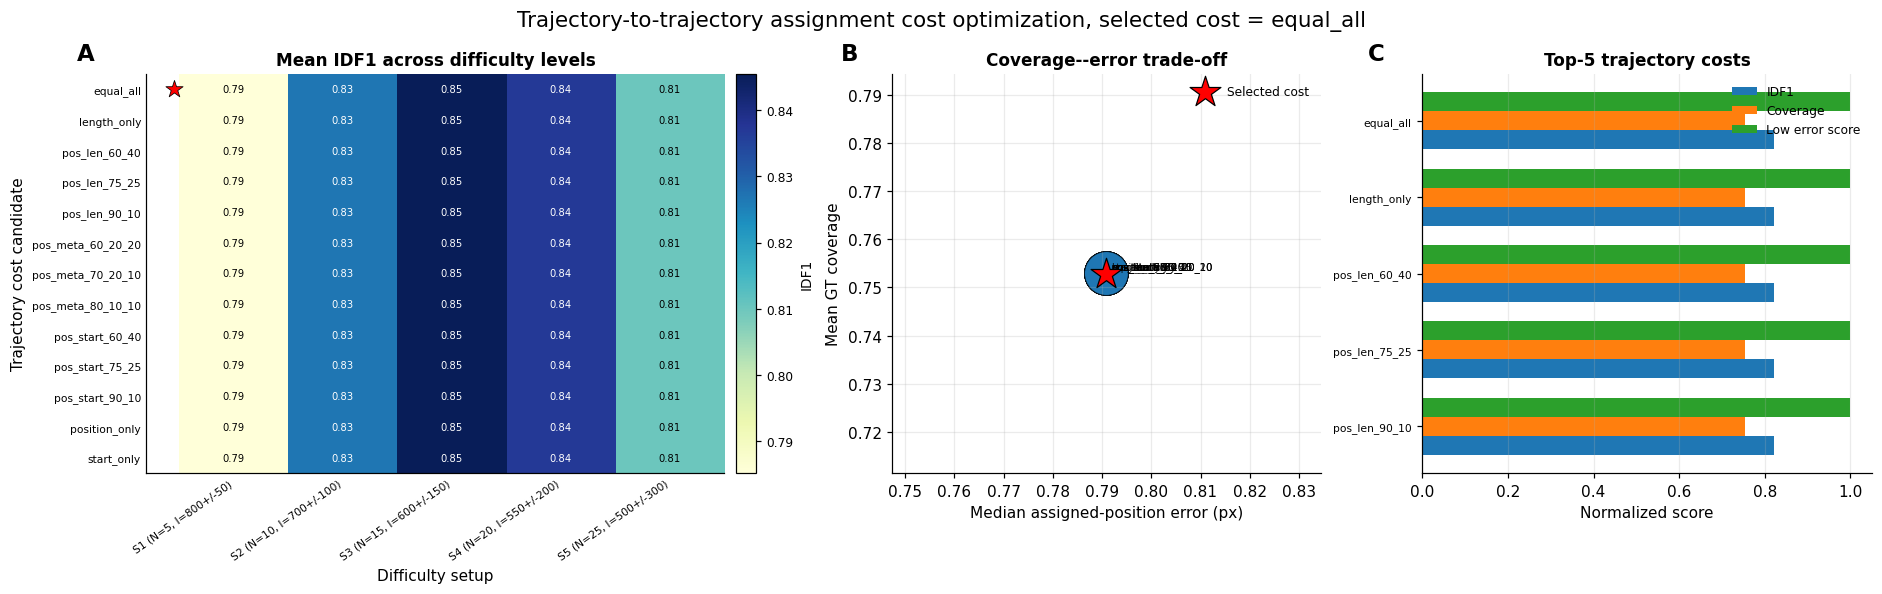

Selected trajectory-to-trajectory cost: equal_all
Saved: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results\CostT2TExperiment_difficulty_intensity_tracking_metrics_traj.png


In [21]:
# Final trajectory-to-trajectory optimization plot
# Panels:
# A: IDF1 heatmap
# B: Coverage vs localization error scatter, bubble size = IDF1
# C: Top-5 candidate costs comparison

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def traj_metric_matrix(df, metric="idf1"):
    return (
        df.groupby(["traj_config", "difficulty"])[metric]
        .mean()
        .unstack("difficulty")
        .reindex(columns=DIFFICULTY_LABELS)
    )


def best_traj_config_from_summary(summary_df):
    return summary_df.iloc[0]["traj_config"]


def plot_heatmap(ax, matrix, best_name, title, cbar_label):
    values = matrix.to_numpy(dtype=float)
    finite = values[np.isfinite(values)]

    vmin = float(finite.min()) if len(finite) else 0.0
    vmax = float(finite.max()) if len(finite) else 1.0

    im = ax.imshow(values, aspect="auto", cmap="YlGnBu", vmin=vmin, vmax=vmax)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns, rotation=35, ha="right", fontsize=7)
    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.set_yticklabels(matrix.index, fontsize=7)
    ax.set_xlabel("Difficulty setup")
    ax.set_ylabel("Trajectory cost candidate")
    ax.tick_params(length=0)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = values[i, j]
            label = "--" if not np.isfinite(val) else f"{val:.2f}"
            color = "white" if np.isfinite(val) and val > vmin + 0.6 * (vmax - vmin) else "black"
            ax.text(j, i, label, ha="center", va="center", fontsize=6.5, color=color)

    if best_name in matrix.index:
        best_idx = list(matrix.index).index(best_name)
        ax.scatter(
            [-0.55],
            [best_idx],
            marker="*",
            s=140,
            color="red",
            edgecolor="black",
            linewidth=0.5,
            zorder=5,
            clip_on=False,
        )

    return im


# Build summary if not already done
traj_df = add_selection_scores(traj_df)

traj_summary = summarize_by_config(
    traj_df,
    config_col="traj_config",
    objective_col="traj_objective",
)

best_traj_name = best_traj_config_from_summary(traj_summary)

idf1_matrix = traj_metric_matrix(traj_df, metric="idf1")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1.35, 1.0, 1.05]},
)

# -------------------------
# Panel A: IDF1 heatmap
# -------------------------
im = plot_heatmap(
    axes[0],
    idf1_matrix,
    best_traj_name,
    title="Mean IDF1 across difficulty levels",
    cbar_label="IDF1",
)

cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.02)
cbar.set_label("IDF1", fontsize=9)
cbar.ax.tick_params(labelsize=8)

# -------------------------
# Panel B: Coverage/error scatter
# -------------------------
ax = axes[1]

x = traj_summary["median_position_error_px_mean"].to_numpy(dtype=float)
y = traj_summary["mean_coverage_mean"].to_numpy(dtype=float)
idf1 = traj_summary["idf1_mean"].to_numpy(dtype=float)

sizes = 80 + 900 * np.nan_to_num(idf1, nan=0.0)

ax.scatter(x, y, s=sizes, alpha=0.65, edgecolor="black", linewidth=0.5)

for _, row in traj_summary.iterrows():
    ax.annotate(
        row["traj_config"],
        (
            row["median_position_error_px_mean"],
            row["mean_coverage_mean"],
        ),
        fontsize=6.5,
        alpha=0.85,
        xytext=(3, 3),
        textcoords="offset points",
    )

best_row = traj_summary.iloc[0]

ax.scatter(
    best_row["median_position_error_px_mean"],
    best_row["mean_coverage_mean"],
    marker="*",
    s=450,
    color="red",
    edgecolor="black",
    linewidth=0.8,
    zorder=10,
    label="Selected cost",
)

ax.set_title("Coverage--error trade-off", fontsize=11, fontweight="bold")
ax.set_xlabel("Median assigned-position error (px)")
ax.set_ylabel("Mean GT coverage")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

# -------------------------
# Panel C: Top-5 cost comparison
# -------------------------
ax = axes[2]

top = traj_summary.head(5).copy()
top = top.iloc[::-1]

labels = top["traj_config"].tolist()
ypos = np.arange(len(top))

idf1_values = top["idf1_mean"].to_numpy(dtype=float)
coverage_values = top["mean_coverage_mean"].to_numpy(dtype=float)
error_values = top["median_position_error_px_mean"].to_numpy(dtype=float)

# Normalize error so that larger is better for visual comparison
# Error score = 1 - normalized error over top-5
if np.nanmax(error_values) > np.nanmin(error_values):
    error_score = 1.0 - (
        (error_values - np.nanmin(error_values))
        / (np.nanmax(error_values) - np.nanmin(error_values))
    )
else:
    error_score = np.ones_like(error_values)

bar_h = 0.25

ax.barh(ypos - bar_h, idf1_values, height=bar_h, label="IDF1")
ax.barh(ypos, coverage_values, height=bar_h, label="Coverage")
ax.barh(ypos + bar_h, error_score, height=bar_h, label="Low error score")

ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Normalized score")
ax.set_title("Top-5 trajectory costs", fontsize=11, fontweight="bold")
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False, fontsize=8)

# -------------------------
# Panel labels
# -------------------------
for label, ax in zip("ABC", axes):
    ax.text(
        -0.12,
        1.08,
        label,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.suptitle(
    f"Trajectory-to-trajectory assignment cost optimization, selected cost = {best_traj_name}",
    fontsize=14,
    y=1.05,
)

fig.savefig(RESULT_PATHS["traj_figure_png"], dpi=300, bbox_inches="tight")

if "traj_figure_pdf" in RESULT_PATHS:
    fig.savefig(RESULT_PATHS["traj_figure_pdf"], bbox_inches="tight")

plt.show()

print("Selected trajectory-to-trajectory cost:", best_traj_name)
print("Saved:", RESULT_PATHS["traj_figure_png"])

In [22]:
best_spec = ...
best_tracks = ...
plot_assigned_trajectories_linear(...)

NameError: name 'plot_assigned_trajectories_linear' is not defined